# RAG Agent -- Process Check

- Create a LLM client
- RAG Prep: register OpenAIEmbeddings, pdf_path, pdf_loader, text_splitter 
- Register page split and the rest of RAG configurations including persist_directory, collection_name
- Make a vectorstore and retriever
- Make a retriever_tool and configure the tool settings
- Set langchain agent state
- Make conditional edge function
- Create the main llm agent fucntion
- Make a retriever agent that acts as manual ToolNode
- Register graph order
- Create the execution function

## RAG Workflow: 
LLM

↓

call_llm()

↓

LLM outputs tool_call

↓

should_continue → True

↓

take_action()

↓

tools_dict["retriever_tool"].invoke(query)

↓

retriever_tool(query)

↓

retriever.invoke(query)

↓

ChromaDB

In [1]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings 
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-5-mini")

## ChromaDB RAG Config

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

pdf_path = "Stock_Market_Performance_2024.pdf"

if not os.path.exists(pdf_path): 
    FileNotFoundError(f"PDF file not found: {pdf_path}")

pages = PyPDFLoader(pdf_path).load()

pdf_loader = PyPDFLoader(pdf_path)

try:
    pages = pdf_loader.load()
    print(f"PDF file was loaded -- {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

pages_split = text_splitter.split_documents(pages)
persist_directory = r"/Volumes/VTG/Dev/LangGraph tutorial"
collection_name = "stock_market"

if not os.path.exists(persist_directory):
    os.makedirs(persist_directory)

PDF file was loaded -- 9 pages


In [5]:
try:
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings, 
        persist_directory=persist_directory,
        collection_name=collection_name
    )
    print("Vector store has been created!")
except Exception as e:
    print(f"Error creating vectorstore: {str(e)}")
    raise

Vector store has been created!


In [6]:
retriever = vectorstore.as_retriever(
    search_type="similarity", 
    search_kwargs={"k": 5}
)

## Tool Function

In [7]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information from the Stock Market Performance 2024 document.
    """

    docs = retriever.invoke(query)
    
    if not docs:
        return "I found no relevant information..."

    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i + 1}:\n{doc.page_content}")

    return "\n\n".join(results)
    

In [8]:
tools = [retriever_tool]

llm = llm.bind_tools(tools=tools)

## LangGraph

In [9]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [10]:
def should_continue(state: AgentState) -> bool:
    """
    Determins whether the graph execution continues based on AI response with a tool call.
    """

    last_msg = state["messages"][-1]

    return hasattr(last_msg,"tool_calls") and len(last_msg.tool_calls) > 0   

In [11]:
# To use this for tool call name validation on AI message later
tool_dict = {tool.name: tool for tool in tools}

In [12]:
def llm_agent(state: AgentState) -> AgentState:
    """
    Function to call the LLM with the current state.
    """

    system_message = """
        You are an intelligent AI assistant who answers questions about Stock Market Performance in 2024 based on the PDF document loaded into your knowledge base.
        Use the retriever tool available to answer questions about the stock market performance data. You can make multiple calls if needed.
        If you need to look up some information before asking a follow up question, you are allowed to do that!
        Please always cite the specific parts of the documents you use in your answers.
    """.strip()

    messages = list(state["messages"])
    messages = [SystemMessage(content=system_message)] + messages

    response = llm.invoke(messages)

    return {"messages": [response]}

### Retriever Agent

In [13]:
def take_action(state: AgentState) -> AgentState:
    """
    Execute tool call validation and the RAG process from LLM's response
    """

    tool_calls = state["messages"][-1].tool_calls
    results = []
    
    for tc in tool_calls:
        tool_name = tc["name"]
        query = tc["args"].get("query", "")
        print(f"Calling Tool\nTool Name: {tool_name}\n Query: {query}")
        
        if tool_name not in tool_dict:
            result = "Invalid tool name"
        else: 
            result = tool_dict[tool_name].invoke(query)

        results.append(
            ToolMessage(
                tool_call_id=tc["id"],
                name=tool_name,
                content=str(result)
            )
        )
    print("Tool execution complete. Back to the LLM")
    return {"messages": results}

### Graph Flow

In [14]:
graph = StateGraph(AgentState)

graph.add_node("llm_agent", llm_agent)
graph.add_node("retriever_agent", take_action)

graph.add_edge(START, "llm_agent")
graph.add_conditional_edges(
    "llm_agent",
    should_continue,
    {True: "retriever_agent", False: END}
)
graph.add_edge("retriever_agent", "llm_agent")

rag_agent = graph.compile()

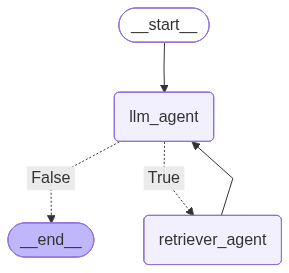

In [15]:
rag_agent

## Run the graph execution

In [16]:
def running_agent():
    print("\n===== RAG AGENT =====")

    while True:
        print("\nAI: What's your question?\n\n")
        user_input = input()

        if user_input.lower() in ["bye", "exit"]:
            break

        user_message = HumanMessage(content=user_input)

        result = rag_agent.invoke({"messages": user_message})

        print("\n===== ANSWER =====")
        print(result["messages"][-1].content)

In [ ]:
if __name__ == "__main__":
    running_agent()


===== RAG AGENT =====

AI: What's your question?




 overall stock market price index in 2024?


Calling Tool
Tool Name: retriever_tool
 Query: overall stock market price index 2024 'price index' 'overall' 'stock market' 2024
Tool execution complete. Back to the LLM

===== ANSWER =====
Summary of the overall 2024 price-index performance (U.S. market):

- S&P 500 (broad benchmark): about +23% in price terms (≈25% total return) — "The benchmark S&P 500 index delivered roughly a 25% total return for 2024 (around +23% in price terms)." (Document 1)  
- Nasdaq Composite: up nearly 29% — "The tech-heavy Nasdaq Composite outpaced the broader market, jumping nearly 29% for the year." (Document 1)  
- S&P 500 Equal-Weight and Russell 2000 (smaller caps): up about 10–11% — "the S&P 500 Equal-Weight index and the Russell 2000 (small-cap benchmark) each rose about 10-11% in 2024." (Document 1)

Note: the rally was concentrated in mega-cap tech names (the "Magnificent 7"), so gains were uneven across the market. (Document 1)

AI: What's your question?




 who are the members of BTS


Calling Tool
Tool Name: retriever_tool
 Query: BTS
Tool execution complete. Back to the LLM

===== ANSWER =====
I searched the PDF collection you provided for "BTS" but the documents returned are about 2024 stock-market topics (for example, Document 1 discusses a "high-growth company" and AI-focused chips) — so the provided documents do not contain information about BTS members (Document 1: "high-growth company - saw its stock skyrocket by approximately 170% in 2024 on the back of insatiable demand for its AI-focused chips"). 

I can still answer from general knowledge (not from your PDFs). The members of BTS are:
- RM (Kim Nam-joon)
- Jin (Kim Seok-jin)
- Suga (Min Yoon-gi)
- J-Hope (Jung Ho-seok)
- Jimin (Park Ji-min)
- V (Kim Tae-hyung)
- Jungkook (Jeon Jung-kook)

Would you like brief bios, stage roles, or birthdates for each member?

AI: What's your question?


